# Classification 
This notbooks is the start to end classification problème that we be the base for the mlops pipeline

## Data visualisation et transformation

In [1]:
!pip install -q monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.2 MB/s eta 0:00:0000:010:01


In [ ]:
import os
import numpy as np
import pandas
import matplotlib.pyplot as plt 
from torch.utils.data import Dataset, DataLoader
from monai.data import CacheDataset
import torch
import torch.nn.functional as F
import pydicom
import torch.nn as nn
import monai.transforms as T
from tqdm import tqdm
import random
import uuid

from dataclasses import dataclass, asdict, field
from accelerate import Accelerator
import wandb
from kaggle_secrets import UserSecretsClient

## config

In [ ]:
ROOT = "/kaggle/input/datasets/borelgoudjou/vindr-spinexr-npz/vindr-spinexr" 
path_train_img = os.path.join(ROOT, "train_images")
path_test_img = os.path.join(ROOT, "test_images")
path_train_csv = os.path.join(ROOT, "annotations", "train.csv")
path_test_csv = os.path.join(ROOT, "annotations", "test.csv")
user_secrets = UserSecretsClient()
wandb_key = user_secrets.get_secret("WANDB_API_KEY")
uuid_tag = uuid.uuid4().hex[:4]

MEAN = 3724.6596
STD = 8457.1860

# efficientnet_b5
# convnext_base
# tf_efficientnetv2_s
# swin_base_patch4_window7_224
# eva02_small_patch14_224
# convnextv2_base

@dataclass
class Config:
    #data
    train_sample: float = 1.0
    train_cache_rate: float = 0.1
    val_sample: float = 0.5
    val_cache_rate: float = 0.4
    ext: str = '.npz'
    kwarg_loader: dict = field(
        default_factory=lambda: {
        "num_workers": 4,
        "pin_memory": True,
        "prefetch_factor": 4,
        "persistent_workers":True,
        "drop_last" :True,
    })
    image_size: tuple= (512, 512)  #
    
    #Model
    model: str = "efficientnet_b3"
    dropout_rate: float = 0.5
    num_classes: int= 8 #len(list(weights.keys()))
    feature_head: int = 0
    uuid_tag: str = uuid_tag
    
    #Train
    epochs: int = 50
    batch_size: int = 32
    learning_rate: float = 1e-4
    gradient_accumulation_steps = 2
    eta_min: float = 1e-6
    optimizer: str = "AdamW"

    # Callback
    patience: int = 15
    max_gap: float = 4.0

config = Config()

In [4]:
wandb.login(key=wandb_key)

# amp_mode if amp_mode in ["bf16","fp16"]
accelerator = Accelerator(mixed_precision="fp16", gradient_accumulation_steps=config.gradient_accumulation_steps, log_with="wandb")
accelerator.init_trackers(
    project_name = "VinDr_Classification",
    config = asdict(config), # tout le fichier config
    init_kwargs = { 'wandb': {
        "entity": "borel237",
        "name": f"{str.capitalize(config.model)}-{uuid_tag}-TIM",
        "reinit": True # Utile si tu lances plusieurs tests à la suite
    }
    }
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: goudjouborel (borel237) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


In [5]:
class XRayDataset(Dataset):
    def __init__(self, img_paths: str, csv_path: str, load_t: T.Compose, runtime_t: T.Compose, sample: float, cache_rate: float, ext: str='.dicom', fixed_classes=None) -> None:
        self.img_paths = img_paths
        self.ext = ext
        df = pandas.read_csv(csv_path)

        # Filtrer les fichiers existants
        self.img_files = [
            os.path.splitext(file)[0] 
            for file in os.listdir(img_paths) 
            if file.endswith(ext) 
        ]
        
        #[file[:-(len(ext))] for file in os.listdir(img_paths)]
        num_elt = len(self.img_files) * sample
        random.shuffle(self.img_files)
        self.img_files = self.img_files[:int(num_elt)]

        # Calculer le poids de classes
        dataframe = df[df['image_id'].isin(self.img_files)].reset_index(drop=True)
        self.classification_data = dataframe.drop_duplicates(['image_id', 'lesion_type']).reset_index(drop=True)
        labels = self.classification_data['lesion_type']

        if fixed_classes is not None:
            self.labels_list = fixed_classes
        else:
            # On extrait l'ordre unique STRICT depuis le CSV d'origine (commun au train et val)
            self.labels_list = sorted(list(df['lesion_type'].unique()))

        self.classification_data['one_hot'] = self.classification_data['lesion_type'].apply(lambda x: [1 if classe in x else 0 for classe in self.labels_list])
        
        counts = labels.value_counts().reindex( self.labels_list)
        weights = counts.sum() / (len( self.labels_list) * counts)
        self.class_weights = weights.to_dict()
        self.labels_list = list(self.class_weights.keys())

        image_labels = (self.classification_data
                        .groupby('image_id')['one_hot']
                        .apply(lambda x: np.array(x.tolist()).max(0))
                       )
                        
        grouped = self.classification_data.groupby('image_id')['one_hot'].apply(lambda x: np.array(x.tolist()).max(0))
        self.label_dict = grouped.to_dict()

        # Calcul des pos_weight de manière sécurisée
        image_labels = np.stack(list(self.label_dict.values()))
        positive_counts = image_labels.sum(axis=0)
        positive_counts = np.clip(positive_counts, 1, None) # Évite la division par 0
        negative_counts = image_labels.shape[0] - positive_counts
        self.pos_weight = negative_counts / positive_counts

        # Cache et transformations
        all_files = [os.path.join(self.img_paths, img_id + self.ext) for img_id in self.img_files]
        self.cached = CacheDataset(data=all_files, transform=load_t, cache_rate=cache_rate, num_workers=8)
        self.runtime = runtime_t

    def __len__(self) -> int:
        return len(self.img_files)

    def __getitem__(self, index):
        try:
            img_id = self.img_files[index]
            label_idx = self.label_dict[img_id]
            img_data = self.runtime(self.cached[index]) 
            
            return img_data, torch.tensor(label_idx, dtype=torch.float32)
            
        except Exception as e:
            # On log l'erreur discrètement pour savoir quel fichier pose problème
            alt_index = random.randint(0, len(self.img_files) - 1)
            return self.__getitem__(alt_index)

In [6]:
# [1266, 2874]
class LoadNPZ(T.Transform):
    def __init__(self, mean=None, std=None):
        self.mean = None if mean is None else torch.tensor(mean, dtype=torch.float32)
        self.std = None if std is None else torch.tensor(std, dtype=torch.float32)

    def __call__(self, data):
        npz = np.load(data)

        img = torch.from_numpy(npz["img"]).float()

        # normalisation bits
        img.div_(2**int(npz["bitsStored"]) - 1)

        # z-score
        if self.mean is not None and self.std is not None:
            img.sub_(self.mean).div_(self.std)

        # ajout canal
        if img.ndim == 2:
            img = img.unsqueeze(0)

        return img
        
cache_transforms = T.Compose([
    LoadNPZ(),
    #T.NormalizeIntensity(subtrahend=MEAN, divisor=STD, nonzero=True),
    T.Resize(spatial_size=config.image_size), #, mode="bilinear"),
])

train_transforms = T.Compose([
    T.RandFlip(prob=0.5, spatial_axis=1),
    T.RandAffine(prob=0.3, rotate_range=(-np.pi/18, np.pi/18), # +/- 10 degrés (36 or 12)
        scale_range=(-0.10, 0.10), translate_range=(-20, 20),     
        spatial_size=config.image_size, padding_mode="nearest" #"reflection" "symmetric"
    ),

    #T.RandHistogramShift(num_control_points=10, prob=1),
    T.RandAdjustContrast(prob=0.2 , gamma=(0.9, 1.1)),
    T.RandGaussianNoise(prob=0.2, mean=0.0, std=0.01),
])

# Pipeline de Validation/Test
val_transforms = T.Compose([
    T.Identity()
    #T.EnsureType(data_type="tensor", dtype=torch.float32)
])

In [7]:
train_dataset = XRayDataset(path_train_img, path_train_csv, cache_transforms, train_transforms, 
                            sample=config.train_sample, cache_rate=config.train_cache_rate, ext=config.ext)

valid_dataset = XRayDataset(path_test_img, path_test_csv, cache_transforms, val_transforms, 
                            sample=config.val_sample, cache_rate=config.val_cache_rate, ext=config.ext, 
                            fixed_classes=train_dataset.labels_list)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False)

Loading dataset: 100%|██████████| 415/415 [00:25<00:00, 16.42it/s]


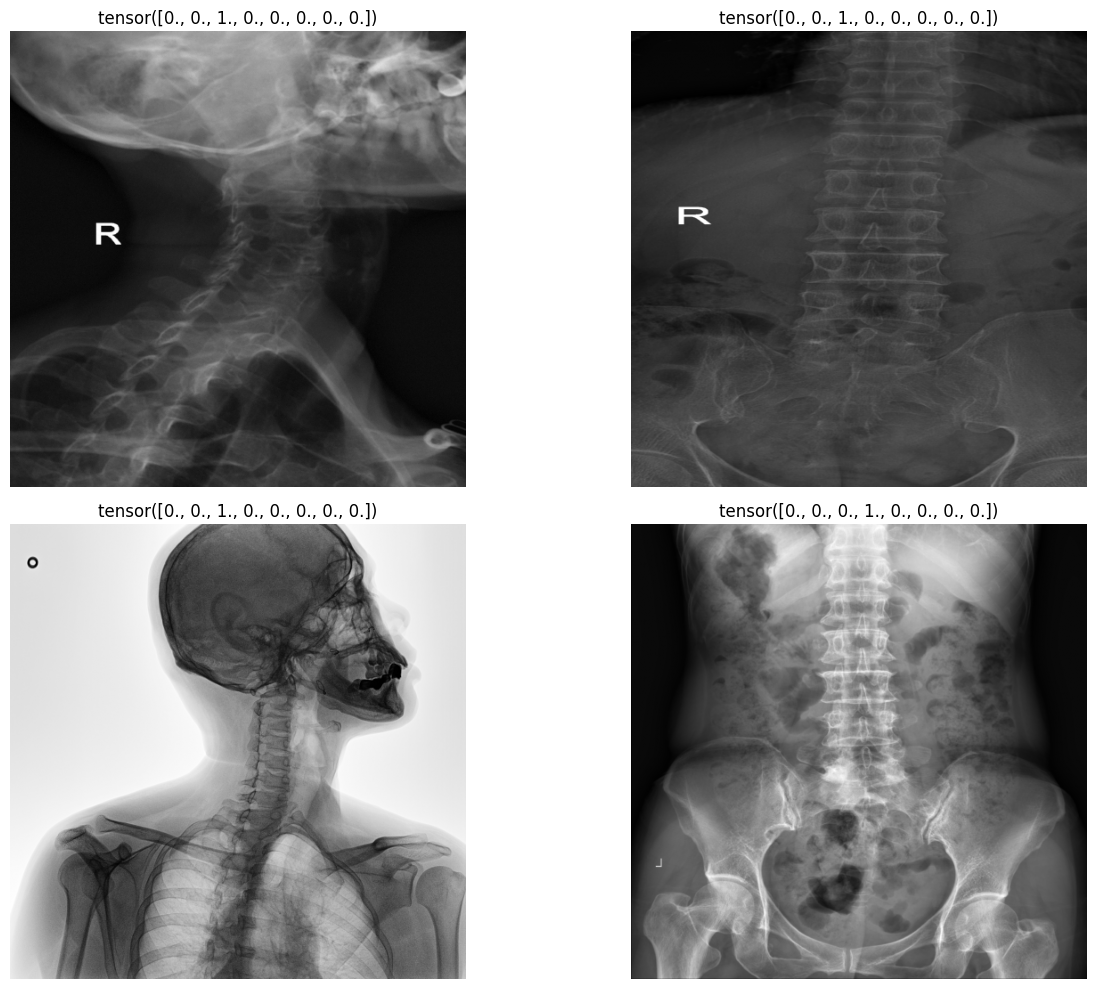

In [8]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
ax = ax.flatten()
for j in range(4):
    i = np.random.randint(len(train_dataset)-1)
    img, label  = train_dataset[i]
    ax[j].imshow(img.squeeze(0).numpy(), cmap='gray')
    ax[j].set_title(label)
    ax[j].axis('off')
    
plt.tight_layout()
plt.show()

## Model

In [9]:
# geler le stem + les 3 premiers blocs
# for param in encoder.model.stem.parameters():
#     param.requires_grad = False

# for block in encoder.model.blocks[:3]:
#     for param in block.parameters():
#         param.requires_grad = False

import timm
class Classifier(nn.Module):
    def __init__(self, model_name: str, num_classes: int, dropout_rate: float, feature_head: int =128) -> None:
        super().__init__()
        # timm gère l'adaptation automatique de 3 canaux à 1 canal !
        self.encoder = timm.create_model(
            model_name, 
            pretrained=True, 
            in_chans=1, 
            num_classes= num_classes if feature_head == 0 else 0,
            #drop_rate=dropout_rate,
            global_pool="avg"
        )
        
        # Récupère automatiquement la dimension de sortie de l'encodeur
        num_features = self.encoder.num_features 
        self.drop = nn.Dropout(p=dropout_rate)
        
        # Votre tête de classification corrigée (feature_head n'est plus None)
        if feature_head is not None:
            self.head = nn.Sequential(
                nn.Linear(num_features, feature_head),
                nn.LayerNorm(feature_head),
                nn.ReLU(),          
                nn.Dropout(dropout_rate),    
                nn.Linear(feature_head, num_classes)
            )
        else:
            self.head = nn.Linear(num_features, num_classes)
            
    def forward(self, x):
        # timm retourne directement la carte de caractéristiques globale (pooled)
        x = self.encoder(x) 
        x = self.drop(x)
        x = self.head(x)
        return x

In [10]:
dummy_input = torch.randn(2, 1, 384, 384) 
model = Classifier(config.model, config.num_classes, dropout_rate = config.dropout_rate, feature_head = 128)

with torch.no_grad():
    pred = model(dummy_input)
    print(f"La prediction est: {pred}")

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

La prediction est: tensor([[ 0.9368, -0.4548,  0.7500,  0.7100, -0.2106,  0.3334,  0.2070,  0.3007],
        [-0.5225,  0.3933, -0.4942, -0.7438, -0.6591,  1.1635,  1.1244, -0.4575]])


## Training

### Loss, schedule and callback

In [11]:
class MultiLabelFocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            weight=self.weight,
            reduction="none"
        )

        prob = torch.sigmoid(logits)

        pt = torch.where(targets == 1,  prob, 1 - prob)

        loss = ((1 - pt) ** self.gamma) * bce

        return loss.mean()

def smooth_labels(targets, epsilon=0.1):
    return targets * (1 - epsilon) + 0.5 * epsilon

In [ ]:
# Create the weights directly on the accelerator's device and Instantiate the criterion
class_weights = torch.tensor(list(train_dataset.class_weights.values()), dtype=torch.float32, device=accelerator.device)
pos_weight = torch.tensor(train_dataset.pos_weight, dtype=torch.float32, device=accelerator.device)
criteron = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
#criteron = SoftmaxFocalLoss(gamma=2.0, weight=class_weights, label_smoothing=0.1).to(accelerator.device)


# Setup optimizer and scheduler normally
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.epochs, eta_min = config.eta_min)

### Train and valid one epoch

In [13]:
def train_one_epoch(model, accelerator, criteron, optimizer, train_loader, epoch, max_grad_norm = 1.0, step_save = 5):
    total_loss = torch.zeros((), device=accelerator.device, dtype=torch.float32)
    optimizer.zero_grad(set_to_none=True)
    model.train()
    
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"training {epoch}: ", disable=not accelerator.is_local_main_process)

    for step, (imgs, labels) in pbar: 
        # Context manager handles gradient accumulation wrapping automatically
        with accelerator.accumulate(model):
            with accelerator.autocast():
                logits = model(imgs)
                loss = criteron(logits, labels)
                
            detached_loss = loss.detach()
            total_loss += detached_loss.float()
            accelerator.backward(loss)
    
            # Gradient accumellation
            if accelerator.sync_gradients:
                if max_grad_norm > 0:
                    accelerator.clip_grad_norm_(model.parameters(), max_grad_norm)
            
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
                    
        # Logger at each step
        if step % step_save == 0:
            pbar.set_postfix({"loss": total_loss.item() / (step+1)})
            if accelerator.is_main_process:
                accelerator.log({"train/loss_step": detached_loss.item(), "batch_step": step, "epoch": epoch})
                
    # Gather across all distributed processes safely
    train_loss = total_loss / len(train_loader)
    train_loss = accelerator.gather_for_metrics(train_loss).mean()
    return {"train/loss": train_loss.item()}


@torch.no_grad()
def eval_one_epoch(model, accelerator,  criteron, test_loader, epoch, metrics_collection):
    metrics_collection.reset()
    total_loss = torch.zeros((), device=accelerator.device, dtype=torch.float32)
    model.eval()
            
    pbar = tqdm(enumerate(test_loader), total=len(test_loader), desc=f"Validation {epoch}: ", disable=not accelerator.is_local_main_process)
    for step, (imgs, labels) in pbar:
        with accelerator.autocast():
            logits = model(imgs)
            loss = criteron(logits, labels)
        total_loss += loss.float()
        pbar.set_postfix({"loss": total_loss.item() / (step+1)})
        
        # torchmetrics s'occupe d'accumuler les données correctement au cours des étapes.
        preds = (torch.sigmoid(logits) > 0.5).float()
        
        metrics_collection.update(preds, labels)
        
    # Calcul de la loss globale (en synchronisant les GPU)
    val_loss = total_loss / len(test_loader)
    val_loss = accelerator.gather_for_metrics(val_loss).mean()

    # Calcul final de toutes les métriques cumulées d'un coup (réduction inter-GPU automatique)
    computed_metrics = metrics_collection.compute()
    
    # On transforme le résultat en dictionnaire de floats simples
    results = {key: val.item() for key, val in computed_metrics.items()}
    results["val/loss"] = val_loss.item()
    
    return results

### Metrics and callback

In [14]:
from torchmetrics import MetricCollection
from torchmetrics.classification import (MultilabelAccuracy, MultilabelF1Score)

classification_metrics = MetricCollection({
    "val/accuracy": MultilabelAccuracy(num_labels=8, average="macro"),
    "val/f1_macro": MultilabelF1Score(num_labels=8, average="macro")
}).to(accelerator.device)

In [15]:
class EarlyStopping:
    def __init__(self, accelerator, config, wandb):
        self.accelerator = accelerator
        self.wandb = wandb
        self.config = config

        self.stop = False
        self.best_val_loss = float("inf")
        self.counter = 0

        # Sécurité au cas où les noms diffèrent dans ton objet config
        self.patience = getattr(config, "patience", 10)
        self.gap_threshold = getattr(config, "max_gap", 1.0)

    def check_and_save(self, model, train_loss, val_loss, epoch):
        # Vérification du Gap (Alerte Overfitting)
        gap = np.abs(train_loss - val_loss)
        if gap >= self.gap_threshold:
            self.accelerator.print(f" Early stopping : Le gap train/val loss est trop grand ({gap:.4f} >= {self.gap_threshold})")
            self.stop = True
            return

        # Vérification de l'amélioration de la Loss de validation
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.counter = 0

            # Seul le processus principal écrit sur le disque pour éviter les conflits
            if self.accelerator.is_main_process:
                # Log de la meilleure valeur sur W&B
                self.accelerator.log({"val/best_loss": val_loss})

                # Sauvegarde du model
                unwrapped_model = self.accelerator.unwrap_model(model)
                model_path = "best_model.pt"
                torch.save(unwrapped_model.state_dict(), model_path)

                # --- ENVOI DE L'ARTÉFACT W&B ---
                try:
                    wandb_tracker = self.accelerator.get_tracker("wandb")
                    artifact = self.wandb.Artifact(
                        name=f"{self.config.model}-{self.config.uuid_tag}",
                        type="model",
                        metadata={
                            "best_val_loss": val_loss,
                            "epoch": epoch,
                            **asdict(self.config),
                        },
                    )

                    artifact.add_file("best_model.pt")
                    wandb_tracker.tracker.log_artifact(artifact, aliases=["best"])
                    
                except Exception as e:
                    self.accelerator.print(f" Erreur lors de l'envoi de l'artéfact W&B : {e}")

        else:
            self.counter += 1
            self.accelerator.print(f"Pas d'amélioration. Patience : {self.counter}/{self.patience}")

        # 3. Déclenchement de l'arrêt si la patience est épuisée
        if self.counter >= self.patience:
            self.accelerator.print(f" Early stopping : Patience atteinte ({self.counter}/{self.patience})")
            self.stop = True

### Trainer


In [ ]:
# Prepare for distributed training
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True,  **config.kwarg_loader)
test_loader = DataLoader(valid_dataset, batch_size=config.batch_size, shuffle=False, **config.kwarg_loader)

model, optimizer, train_loader, test_loader, scheduler = accelerator.prepare(model, optimizer, train_loader, test_loader, scheduler)
early_stopping = EarlyStopping(accelerator, config, wandb)

# Setup WandB Gradient Watching on the main process
if accelerator.is_main_process:
    wandb_tracker = accelerator.get_tracker("wandb")
    # watch expects the raw/unwrapped model to properly track layers
    unwrapped_model = accelerator.unwrap_model(model)
    wandb_tracker.run.watch(unwrapped_model, log="all", log_freq=50)

best_accuracy = 0.0
for epoch in range(config.epochs):
    # Evaluate and log
    val_scores = eval_one_epoch(model, accelerator, criteron, test_loader, epoch, classification_metrics)
    accelerator.log(val_scores)
    accelerator.print(f"Epoch {epoch} - Val loss: {val_scores['val/loss']:.4f}, Accuracy: {val_scores['val/accuracy']:.4f}, F1-score: {val_scores["val/f1_macro"]:.4f}")

    
    # Train and log
    train_loss = train_one_epoch(model, accelerator, criteron, optimizer, train_loader, epoch)
    scheduler.step()
    accelerator.log({**train_loss, "train/lr_scheduler": scheduler.get_last_lr()[0]})
    accelerator.print(f"Epoch {epoch} - Train loss: {train_loss['train/loss']:.4f}")

    
    # Save best model checkpoint & log artifact
    early_stopping.check_and_save(model, train_loss["train/loss"], val_scores['val/loss'], epoch)
    if early_stopping.stop:
        break

Validation 0:   0%|          | 0/32 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Validation 0: 100%|██████████| 32/32 [13:34<00:00, 25.45s/it, loss=1.27]


Epoch 0 - Val loss: 1.2744, Accuracy: 0.3914, F1-score: 0.1081


training 0:   0%|          | 0/260 [00:00<?, ?it/s]